# 01 — Data integrity and EDA

**Stage 1** of the time-series analytics project. Before any
smoothing or STL claim we verify the data can support a regular
daily index (data integrity, golden standard #1) and describe the
network's shape and scale (EDA).

**Status: EXPLORATORY (hypothesis-generating).** Nothing in this
notebook is a significance claim; findings here only inform later
stages.

**Unit of analysis (unit of analysis):** one row = sales of one
product `family` in one `store_nbr` on one `date`, the Kaggle
schema `id, date, store_nbr, family, sales, onpromotion`.


In [1]:
%matplotlib inline
import sys, pathlib
root = pathlib.Path.cwd()
while root != root.parent and not (root / 'data' / 'train.csv').exists():
    root = root.parent
if not (root / 'data' / 'train.csv').exists():
    raise FileNotFoundError('could not locate data/train.csv')
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
DATA = root / 'data' / 'train.csv'
from src.eda import (
    load_train, integrity_report, assert_integrity,
    daily_network_sales, store_daily_sales, store_type,
    pick_stl_stores, promotion_share,
)
df = load_train(DATA)
df.head()

,id,date,store_nbr,family,sales,onpromotion,type
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,D
1,1,2013-01-01,1,BABY CARE,0.0,0,D
2,2,2013-01-01,1,BEAUTY,0.0,0,D
3,3,2013-01-01,1,BEVERAGES,0.0,0,D
4,4,2013-01-01,1,BOOKS,0.0,0,D


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Data integrity (data integrity)

Checks performed: completeness (no missing per column), uniqueness
(no duplicate `(date, store_nbr, family)` keys), value sanity
(`sales >= 0`, `onpromotion` range), and calendar continuity
(every day between min and max `date` present). The calendar check
matters most: smoothing and STL in later stages assume a regular
daily index.


In [3]:
report = integrity_report(df)
print(f"rows: {report['n_rows']:,}")
print(f"date range: {report['date_min']} .. {report['date_max']}")
print(f"stores: {report['n_stores']}, families: {report['n_families']}")
print(f"duplicate (date, store, family) keys: {report['n_duplicate_keys']}")
print(f"missing values per column: {report['missing_per_column'].to_dict()}")
print(f"sales min/max: {report['sales_min']:,.2f} / {report['sales_max']:,.2f}")
print(f"zero-sales row share: {report['zero_sales_share']:.2%}")
print(f"onpromotion min/max: {report['onpromotion_min']} / {report['onpromotion_max']}")
print(f"missing calendar days: {report['n_missing_calendar_days']} -> "
      f"{report['missing_calendar_days']}")

rows: 3,000,888
date range: 2013-01-01 .. 2017-08-15
stores: 54, families: 33
duplicate (date, store, family) keys: 0
missing values per column: {}
sales min/max: 0.00 / 124,717.00
zero-sales row share: 31.30%
onpromotion min/max: 0 / 741
missing calendar days: 4 -> ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']


In [4]:
try:
    assert_integrity(df)
    print('assert_integrity: PASS — frame is valid for analysis.')
except ValueError as err:
    print(f'assert_integrity surfaced: {err}')

assert_integrity surfaced: calendar is not continuous; missing dates: 2013-12-25, 2014-12-25, 2015-12-25, 2016-12-25


### Calendar verdict and the 0-fill decision (pre-registered)

The frame spans **2013-01-01 .. 2017-08-15**, but only **1684** of
**1688** calendar days are present. The four missing days are
**Dec 25, 2013-2016**: no rows exist for any store on those dates
(`integrity_report` computed this above from train.csv alone). We
interpret the absence as a Christmas closure of the network, and
that interpretation is the 0-fill rationale.

Handling (decided here and re-used by every downstream stage):
`daily_network_sales` / `store_daily_sales` reindex to the full
calendar and **fill the closure days with 0** — an absent row means
zero recorded sales, and a gapless daily index is what MA/STL
require. `NaN` is rejected because it would poison every rolling
window around the gap; dropping the days would break the regular
grid. `assert_integrity` still raises on gaps — the hard gate stays
strict, and the 0-fill is a conscious, documented exception.


## 2. Daily network sales (decomposition target)

**Question:** what does the whole network's daily sales look like
over 2013-2017 — level, spread, spikes? This is the series the MA/STL
stages smooth and decompose.


In [5]:
daily = daily_network_sales(df)
print(f"series length: {len(daily)} (full calendar incl. 4 filled closures)\n")
print(daily.describe().to_string())
print(f"\nmin..max: {daily.min():,.0f} .. {daily.max():,.0f}")

series length: 1688 (full calendar incl. 4 filled closures)

count       1,688.00
mean      636,045.56
std       236,176.59
min             0.00
25%       440,805.26
50%       631,692.56
75%       785,579.94
max     1,463,084.00

min..max: 0 .. 1,463,084


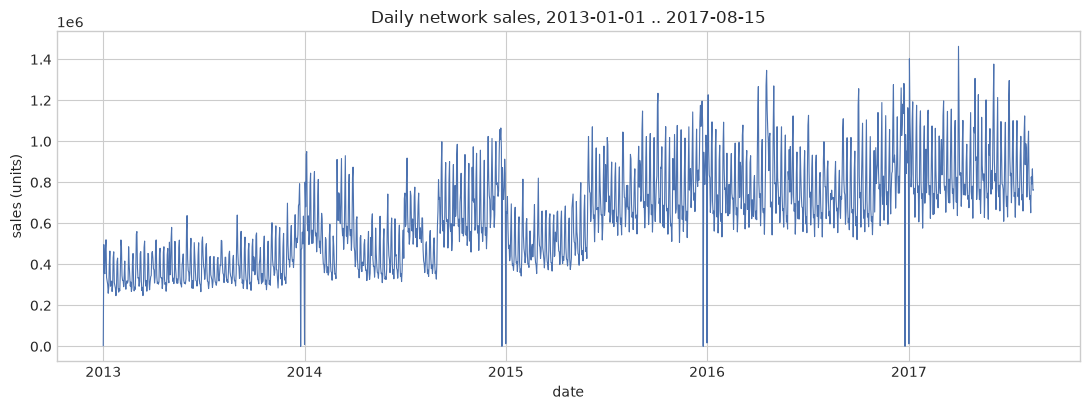

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(daily.index, daily.values, lw=0.8, color='#4C72B0')
ax.set_title('Daily network sales, 2013-01-01 .. 2017-08-15')
ax.set_xlabel('date')
ax.set_ylabel('sales (units)')
fig.tight_layout()
fig.savefig('../assets/eda_daily_sales.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Weekly profile (weekday seasonality)

**Question:** which days of the week sell more? A stable weekday
pattern is exactly what a `period=7` STL is meant to capture.


In [7]:
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly = daily.groupby(daily.index.dayofweek).mean()
weekly.index = [weekday_names[i] for i in weekly.index]
print(weekly.to_string())

Mon   617,542.69
Tue   569,926.06
Wed   590,782.94
Thu   503,172.66
Fri   577,169.44
Sat   772,205.62
Sun   821,794.00


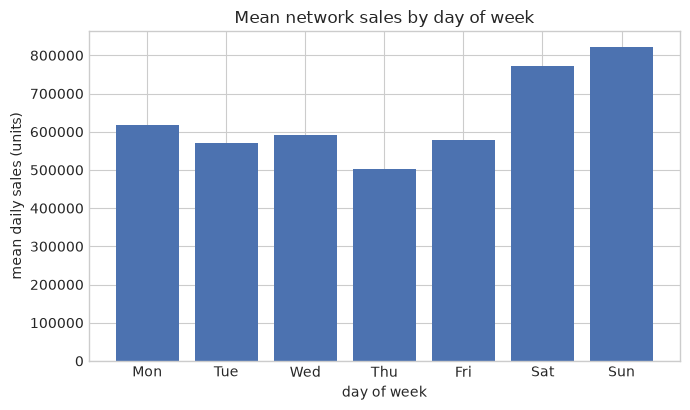

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(weekly.index, weekly.values, color='#4C72B0')
ax.set_title('Mean network sales by day of week')
ax.set_xlabel('day of week')
ax.set_ylabel('mean daily sales (units)')
fig.tight_layout()
fig.savefig('../assets/eda_weekday_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Promotions over time (promo share)

**Question:** how much of the assortment runs a promotion, and is
promo activity stationary? `promotion_share` is the raw share of
rows with `onpromotion > 0` per day — a visibility view, not a
causal claim.


In [9]:
promo = promotion_share(df)
print(f"overall share of promo rows: {(df['onpromotion'] > 0).mean():.2%}")
print(f"daily share min / mean / max: "
      f"{promo.min():.2%} / {promo.mean():.2%} / {promo.max():.2%}")
print("\nmean daily promo share by year:")
print(promo.groupby(promo.index.year).mean()
      .map(lambda v: f'{v:.2%}').to_string())

overall share of promo rows: 20.37%
daily share min / mean / max: 0.00% / 20.37% / 56.17%

mean daily promo share by year:
date
2013     0.00%
2014    10.02%
2015    20.86%
2016    35.05%
2017    45.26%


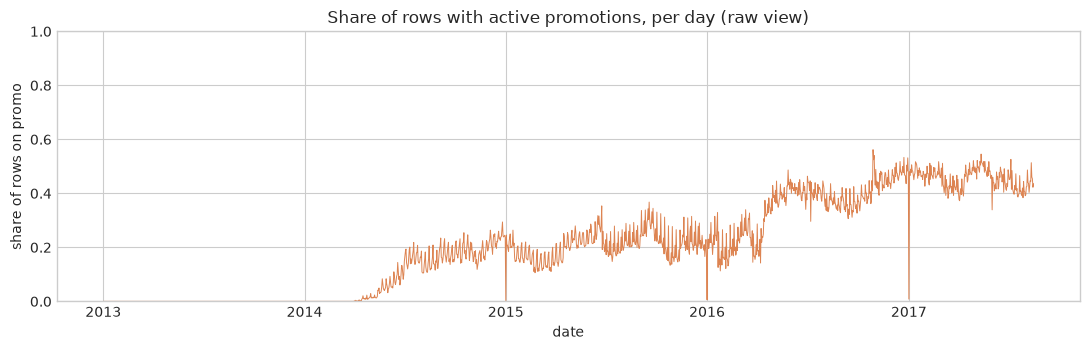

In [10]:
# Embedded EDA figure only (option from the plan: promo is not an
# assets/ file — the stage's two named figures are the sales series
# and the weekday profile).
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(promo.index, promo.values, lw=0.7, color='#DD8452')
ax.set_title('Share of rows with active promotions, per day (raw view)')
ax.set_xlabel('date')
ax.set_ylabel('share of rows on promo')
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

## 5. Top stores by total sales

**Question:** how concentrated is the network? This sets the scale
for store-level smoothing later.


In [11]:
totals = df.groupby('store_nbr')['sales'].sum().sort_values(ascending=False)
top = totals.head(10).to_frame('total')
top['type'] = [store_type(df, s) for s in top.index]
print(top.round(0).to_string())

                  total type
store_nbr                   
44        62,087,552.00    A
45        54,498,012.00    A
47        50,948,312.00    A
3         50,481,912.00    D
49        43,420,096.00    A
46        41,896,064.00    A
48        35,933,132.00    A
51        32,911,490.00    A
8         30,494,286.00    D
50        28,653,020.00    A


## 6. STL store pick (pre-registered, fixed here)

Task 3 decomposes **two** stores. The rule is fixed now so the pick
cannot be revisited after decomposition results are visible: the
largest type-**A** store (same format for peak seasonality) plus the
smallest type-**D**/**E** store (a different channel scale). The pick
is computed by `pick_stl_stores`, the single decision source used by
notebooks 01 and 03.


In [12]:
picked = pick_stl_stores(df)
for s in picked:
    total = float(df.loc[df['store_nbr'] == s, 'sales'].sum())
    print(f'store {s} (type {store_type(df, s)}): total sales {total:,.0f}')
print(f'\nSTL stores for Task 3: {picked}')

store 44 (type A): total sales 62,087,552
store 26 (type D): total sales 7,755,122

STL stores for Task 3: [44, 26]


## 7. Stage conclusion

- Frame is clean: **3,000,888** rows, 2013-01-01 .. 2017-08-15,
  **54** stores, **33** families; no duplicates, no missing values,
  `sales` in [0, 124,717], `onpromotion` in [0, 741]; 31.3% of rows
  are zero-sales (assortment days without a sale — structural zeros).
- Calendar is **not** gapless: **Dec 25, 2013-2016** are absent for
  the whole network (Christmas closure). They are 0-filled in both
  daily series functions; `assert_integrity` surfaced this loudly and
  the decision is documented in notes/01.
- Network daily sales: mean ≈ 636k, median ≈ 632k, max ≈ 1.46M;
  a strong weekend effect — Sun ≈ 822k, Sat ≈ 772k vs a Thu trough
  ≈ 503k — confirms a clear weekly seasonality for `period=7` STL.
- Promotions are **not** stationary: daily promo share climbed from
  ~0% (2013) to ~45% (2017), peaking at 56% of rows — promo is a
  growing business policy and a candidate driver of level shifts.
- STL stores fixed here: **store 44 (type A, largest)** and
  **store 26 (type D, smallest D/E)** — used unchanged by Task 3.
